Missing Values (Before Cleaning):
Date                         0.000000
Aceh                         3.685259
Bali                         3.585657
Banten                       3.685259
Bengkulu                     3.685259
DI Yogyakarta                3.585657
DKI Jakarta                  3.685259
Gorontalo                    3.486056
Jambi                        3.784861
Jawa Barat                   3.685259
Jawa Tengah                  3.386454
Jawa Timur                   3.486056
Kalimantan Barat             3.585657
Kalimantan Selatan           3.685259
Kalimantan Tengah            3.585657
Kalimantan Timur             3.884462
Kalimantan Utara             3.884462
Kepulauan Bangka Belitung    3.784861
Kepulauan Riau               3.884462
Lampung                      3.685259
Maluku Utara                 3.585657
Maluku                       3.685259
Nusa Tenggara Barat          3.685259
Nusa Tenggara Timur          3.386454
Papua Barat                  3.884462
Papua           

d:\Anaconda\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning:

Argument `input_shape` is deprecated. Use `shape` instead.



Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - loss: 67.0185 - mape: 67.0185 - val_loss: 28.3876 - val_mape: 28.3876 - learning_rate: 0.0030
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 27.7446 - mape: 27.7446 - val_loss: 25.8241 - val_mape: 25.8241 - learning_rate: 0.0030
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 20.6328 - mape: 20.6328 - val_loss: 10.8451 - val_mape: 10.8451 - learning_rate: 0.0030
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 18.4320 - mape: 18.4320 - val_loss: 20.2990 - val_mape: 20.2990 - learning_rate: 0.0030
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 19.0661 - mape: 19.0661 - val_loss: 8.2439 - val_mape: 8.2439 - learning_rate: 0.0030
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 16.9761 - mape: 16.9761 - val_loss: 23.7898 - val_mape: 23.7898 - learning_rate: 0.0030
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 15.6749 - mape: 15.6749 - val_loss: 7.2751 - val_mape

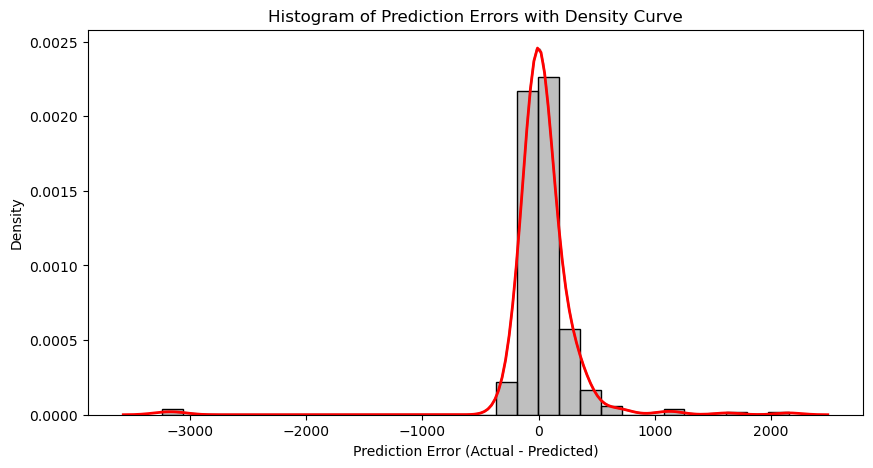

In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load dataset
df = pd.read_csv("Dataset/Harga Bahan Pangan/train/Gula Konsumsi.csv")

# Cek missing values
missing_percent_df = df.isnull().sum() / len(df) * 100
print("Missing Values (Before Cleaning):")
print(missing_percent_df)

# Isi missing values dengan interpolasi linier untuk mengikuti tren data
numeric_features = df.select_dtypes(include=['number']).columns
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())

# Cek kembali setelah interpolasi
print("Missing Values (After Interpolation):")
print(df.isnull().sum())

# Fungsi untuk membentuk sequence data time series
def df_to_X_y(df, window_size=5):
    X, y = [], []
    for i in range(len(df) - window_size):
        X.append(df[i:i+window_size])
        y.append(df[i + window_size])
    return np.array(X), np.array(y)

# Preprocess data
df = df.select_dtypes(include=[np.number])
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# Ambil hanya satu kolom jika ada banyak numeric columns
if df.shape[1] > 1:
    print(f"Warning: DataFrame has multiple numeric columns ({df.shape[1]}). Using the first column.")
    df = df.iloc[:, 0]

# StandardScaler untuk normalisasi
scaler = StandardScaler()
df = scaler.fit_transform(df.values.reshape(-1, 1))

# Membentuk sequence data
window_size = 5
X, y = df_to_X_y(df, window_size)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False, random_state=SEED)

# Callbacks untuk training
checkpoint_path = "model_checkpoint.keras"
cp4 = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_best_only=True, monitor='val_loss', mode='min')
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=5, min_lr=1e-6, verbose=1)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Fungsi untuk membuat model LSTM
def create_lstm_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=input_shape),
        tf.keras.layers.LSTM(128, return_sequences=True),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.LSTM(32, return_sequences=False),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='linear')
    ])
    model.compile(loss='mape', optimizer=tf.keras.optimizers.Adam(learning_rate=0.003), metrics=['mape'])
    return model

# Training model
input_shape = (X_train.shape[1], X_train.shape[2])
model = create_lstm_model(input_shape)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=1, callbacks=[cp4, lr_reducer, early_stopping])

# Simpan model
model.save("lstm_model.keras")

# Prediksi data test
y_pred = model.predict(X_test)

# Kembalikan ke skala asli
y_test_original = scaler.inverse_transform(y_test)
y_pred_original = scaler.inverse_transform(y_pred)

# Hitung MAPE
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

error = mape(y_test_original, y_pred_original)
print(f"MAPE: {error:.2f}%")

# Load sample submission
df_submission = pd.read_csv("Dataset/Harga Bahan Pangan/sample_submission.csv")
unique_countries = df_submission['id'].str.split('/').str[1].unique()
total_required_predictions = 92 * len(unique_countries)

# Prediksi harga masa depan
future_predictions = []
input_seq = X_test[-1]

for _ in range(total_required_predictions):
    pred = model.predict(input_seq.reshape(1, window_size, 1))[0, 0]
    pred += np.random.normal(0, 0.01)  
    future_predictions.append(pred)
    input_seq = np.roll(input_seq, -1)
    input_seq[-1] = pred

# Kembalikan hasil prediksi ke skala asli
y_pred_future = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Format file submission
data = []
for i in range(min(len(df_submission), len(y_pred_future))):
    data.append({'id': df_submission.iloc[i]['id'], 'price': y_pred_future[i][0]})

submission_df = pd.DataFrame(data)
submission_df.to_csv("gula_konsumsi_submission_new.csv", index=False)
print("Submission file saved as gula_konsumsi_submission_new.csv")

# Visualisasi Error
errors = y_test_original.flatten() - y_pred_original.flatten()
df_errors = pd.DataFrame({'Error': errors})

plt.figure(figsize=(10, 5))
sns.histplot(errors, bins=30, kde=True, color="gray", stat="density", edgecolor='black')
sns.kdeplot(errors, color='red', linewidth=2)
plt.title("Histogram of Prediction Errors with Density Curve")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Density")
plt.show()
